In [1]:
#############################################
##### this is a test script for axolotl tracking 
##### modified based on the original code https://github.com/vivekhsridhar/tracktor/blob/master/examples/3g%20Zebrafish_schooling.ipynb
##### run_1 for all videos in Animal 15, 27, 34, 39
##### add the adaptive threshold searching using the upper quantile of image intensity, change the quantile 0.995
##### add the bigger range for circle searching maxRadius
##### change the circle radius
##### second run for A39 which didn't pass for the frist run
##### 1) manually ajust the circle coordinates and radius for A39_1wpt_5_L2
##### 2) optimize again the circle searching: reduce the distance parameter and ajust the dp parameters to get more fitted circles;  
#####    then select the smallest inner circles
##### 3) add test mode
##### 4) A34 animals for 8wpt using the general parameters for circle searching but threshold_quantile = 0.995; A34_preONT_1 (_2,_3) has issue with circle detection and low intensity of animal
#####    A34_preONT_1 last 1000 frame with no animal detected. circles_dp = 2, circle_dist = 4, circle_offset = 5, threshold_quantile = 0.995
##### 5) A27 A27_1wpt_3_L1 with two bands with high reflexion;
##### 6) to be consistance with early version of parameters, turn off the param1 and param2; all control parameters for circle detection is dp, minDist and offset (after first run of A27)
##### 7) test for A15
##### 8) run massive videos for 7 animals
##### 9) save the original image size and scaling factors x, y 
##### test the v1.3 beta version to run second notebook in parallel
##### this v1.3 beta mainly to test how to process the video with errors
##### the main issue comes from two sources : 
##### E1: circle is not properly identified
##### E1 solution: try new method of circle searching circle_ostu_floodfill_contour_mincircle, debug the function and fix the bug, should copy the image instead of "=", otherwise the image will be  
##### modified by the function, because of the same memory location
##### E2: the animal intensity and background, some animals have extremly dimme intensity and/or high background
##### E2 solution is to increase the intensity quantile for the threshold searching
##### used 0.997 intensity qunatile for A34_preONT_1_L1, A15_1wpt_3_D2
#############################################

In [2]:
import numpy as np
import pandas as pd
import tracktor as tr
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os
from pathlib import Path
import math
from skimage.io import imread
from skimage import filters
import gc

In [3]:
## try to speed up the cv2 calling 
print(cv2.useOptimized())
cv2.setUseOptimized(True)
print(os.cpu_count())
cv2.setNumThreads(1)

True
10


In [4]:
## global function to find alternative circle with fllodfill, findcontour and find minimal circle 
def circle_ostu_floodfill_contour_mincircle(frame, circle_center):
    
    frame_ring = frame.copy()
    
    circle_x = circle_center[0]
    circle_y = circle_center[1]
    
    mask_ring = np.zeros(frame_ring.shape)
    mask_ring = cv2.circle(mask_ring, (circle_x, circle_y), 150 , (255,255,255), -1)
    
    frame_ring[mask_ring ==  0] = 0
    
    ## gaussian blur
    gray_ring = cv2.cvtColor(frame_ring, cv2.COLOR_BGR2GRAY)
    blur_ring = cv2.GaussianBlur(gray_ring, (5, 5), 0)
    #plt.imshow(blur_ring,'gray')
    
    _, image_th = cv2.threshold(blur_ring, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU, )
    #print("Obtained threshold: ", otsu_threshold)
    
    # Copy the thresholded image.
    im_floodfill = image_th.copy()
    # Mask used to flood filling.
    # Notice the size needs to be 2 pixels than the image.
    h, w = image_th.shape[:2]
    mask_floodfill = np.zeros((h+2, w+2), np.uint8)
    
    # Floodfill from point (0, 0)
    cv2.floodFill(im_floodfill, mask_floodfill, (0,0), 255);
    #cv2.floodFill(im_floodfill, mask_floodfill, (250,250), 255);
    #plt.imshow(im_floodfill,'gray')
    
    cv2.floodFill(im_floodfill, mask_floodfill, (299, 299), 255);
    cv2.floodFill(im_floodfill, mask_floodfill, (0, 299), 255);
    cv2.floodFill(im_floodfill, mask_floodfill, (299, 0), 255);
    #plt.imshow(im_floodfill,'gray')
    
    # Invert floodfilled image
    im_floodfill_inv = cv2.bitwise_not(im_floodfill)
    #plt.imshow(im_floodfill_inv,'gray')
    
    contours, hierarchy = cv2.findContours(im_floodfill_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #disk = np.zeros_like(im_floodfill_inv)

    if contours:
        biggest_contour = max(contours, key=cv2.contourArea)
    
        (x, y), radius = cv2.minEnclosingCircle(biggest_contour)
        
        #center = (int(x), int(y))
        #radius = int(radius)
        
        #print("Center:", center)
        #print("Radius:", radius)
        circle_new = [int(x), int(y), int(radius)]
        # Draw circle for visualization
        #output = cv2.cvtColor(im_floodfill_inv, cv2.COLOR_GRAY2BGR)
        #cv2.circle(output, center, radius, (0, 255, 0), 2)
        #cv2.circle(output, center, 2, (0, 0, 255), 3)
        
        #cv2.imshow("Minimal enclosing circle", output)
        #cv2.waitKey(0)
        
        #cv2.drawContours(disk, [biggest_contour], -1, 255, thickness=cv2.FILLED)
        return circle_new
        
    else:
        
        return None
    

## Global parameters
This cell (below) enlists user-defined parameters

In [5]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
#colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]
colours = [(0,0,255),(0,255,255),(255,0,255), (255,255,0),(255,0,0),(0,255,0)]

# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
#block_size = 51
#offset = 20

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
# not use fixed scaling, rather calculate the scaling_img to reduce the all images to 300*300
#scaling = 1.0 

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

## parameters added for axolotl images
nb_skippedFrame = 700 # nb of frames to skip to make sure axolotl is there

## parameters for the circle searching
minRadius_init = 120
maxRadius_init = 140

## main parameters to ajust for videos/animals
circles_dp = 1 # 1, 1.2, 1.5 or 2.0
circle_dist = 4 # 2, 4, 50  
circle_offset = 4 # 2, 4, 6, 8
circle_offset_alt = 4

threshold_quantile = 0.997 #use the adpative thresholding searach, this parameter used when the animal with high intensity and circle border is dim
#threshold_quantile = 0.995 # thise parameter is generally used


# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 100 
max_area = 800
min_circularity = 0.1 ## minimum circularity of object for detected animal

#### 
display_outFrame = True
test_processing = False

In [6]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Deinz_axolot_tracking/run_1/to_process_2ndround/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/processed_2round/'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if test_processing:
    output_dir = output_dir + 'test/'

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/processed_2round/


In [7]:
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]

print("nb of videos to process: " + str(len(folder_names)) + ":")
#print('-----')
print(folder_names)

nb of videos to process: 4:
['A5_1wpt_3_D3', 'A15_preONT_1_D1', 'A15_1wpt_3_D2', 'A58_1wpt_1_D1']


In [8]:
## test only specific video
folder_names = folder_names[2]

#print(folder_names)
#if isinstance(folder_names, str):
#    folder_names = [folder_names]
#for folder in folder_names:
#    print(folder)
print(folder_names)
print(len(folder_names))

A15_1wpt_3_D2
13


In [15]:
###############################################
##### run all videos in the specified folders
###############################################

In [9]:
if isinstance(folder_names, str):
    folder_names = [folder_names]
    
for folder in folder_names:
    
    ## Start time
    start = time.time()
    
    print(folder)
    
    video = folder
    output_vidpath = output_dir + video + '.mp4'
    output_filepath = output_dir + video + '.csv'
    output_figpath = output_dir + video + '.pdf'
    output_error = output_dir + video + '_error.csv'
    output_circle = output_dir + video + '_circle.csv'
    
    video_path = Path(input_vidpath + folder + '/')
    
    first_file = next(p.name for p in video_path.iterdir() if p.is_file() and p.name.endswith(".tiff"))
    
    #first_file = next(p.name for p in video_path.iterdir() if p.is_file())
    #files = [p for p in video_path.iterdir() if p.is_file()]
    #first_file = files[0].name
    file_name = Path(first_file).stem
    #print(file_name)
    file_split = file_name.split("_")
    f_newname = "_".join(file_split[:-1])
    
    print(f_newname)
    #'1_D1_test/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
    
    ##########
    # check the image size of first file to determine the scaling parameter for x and y
    # scale all images to 300*300 pixels
    ##########
    img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
    scaling_img_0 = 300/img.shape[0]
    scaling_img_1 = 300/img.shape[1]
    
    img_shape = img.shape
    
    print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
    print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))
    
    del img
    
    ###################################################
    ### loop over videos
    ###################################################
    ## Open video
    cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
    if cap.isOpened() == False:
        sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

    ## Video writer class to output video with contour and centroid of tracked object(s)
    # make sure the frame size matches size of array 'final'
    fourcc = cv2.VideoWriter_fourcc(*codec)
    output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
    print('output_framesize -- ' + str(output_framesize[0]) + ', ' +  str(output_framesize[1]))
    
    out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

    ## Individual location(s) measured in the last and current step
    meas_last = list(np.zeros((n_inds,2)))
    meas_now = list(np.zeros((n_inds,2)))
    
    last = 0
    df = []
    err = []
    
    ## first frame to detect the coordinate and radius of circles
    #cap.set(1,1)
    ## strat the tracing from the frame 500 to skip those without axolotl
    cap.set(1, nb_skippedFrame)
    
    ret, frame = cap.read()
    
    frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
    
    print(frame.shape)
    
    ###################################################
    ### circle searching
    ### add adapt circle searching with maxRadius
    ###################################################
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur_frame = cv2.medianBlur(gray_frame, 5)
    
    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)
    circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = maxRadius_init) ## add param1 and param2; reduce the distance 
    
    if circles is None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 5))
        circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = (maxRadius_init + 5)) ## add param1 and param2; reduce the distance 
        
        if circles is None:
            #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 10))
            circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = (maxRadius_init + 10)) 
            
    
    if circles is not None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 10, minRadius = 120, maxRadius = 150)
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
        
        circles = np.round(circles[0, :]).astype("int")
        
        # Sort by radius, smallest first
        circles = sorted(circles, key=lambda c: c[2])

        # Smallest circle with general parameteres
        circle_run = circles[0]
        
        circle_x = circle_run[0]
        circle_y = circle_run[1] 
        circle_radius = circle_run[2] - circle_offset
        
        #circles = np.uint8(np.around(circles))
        #print(circle_run)
        #if len(circles) == 1:
        #    circle_run = circles[0,:][0]
        #else:
        #    print(' > 1 circles found but select the first one ')
        #    circle_run = circles[0,:][0]
        #circle_x = circle_run[0]
        
        ## general parameters
        #circle_y = circle_run[1]
        #circle_radius = 130
        #circle_radius = circle_run[2] - 2
        
        # ajust parameter for A39_1wpt_5_L2
        #circle_y = circle_run[1] + 3
        #circle_radius = circle_run[2] - 5
        
        circle_position = [circle_x, circle_y, circle_radius]
        
        print(circle_position)
        
        ### add alternative circle searching function
        try:
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            #print(circle_new)
            
            #circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            #print(circle_new2)
            
            circle_new = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            print(circle_new)
            
            
            if circle_new is not None and circle_new[2] >= 110:
                circle_new[2] = circle_new[2] - circle_offset_alt
                circle_position = circle_new
                
            else:
                print('search for alternative circle for 2nd time')
                #circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
                circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
                print(circle_new2)
                
                if circle_new2 is not None and circle_new2[2] >= 110:
                    circle_new2[2] = circle_new2[2] - circle_offset_alt
                    circle_position = circle_new2
                else:
                    print('no alternative circle found')
                    
        except:
            print("error in the alternative circle searching")
            
            
        print(circle_position)
        
        circle_coord = circle_position.extend([img_shape[0], img_shape[1], scaling_img_0, scaling_img_1])
        circle_coord = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius', 'originalImage_x', 'originalImage_y', 'scaling_x', 'scaling_y'])
        
        circle_coord.to_csv(output_circle, sep=',')
        
    else:
        print(' no circles found !!! ')
        #break
        continue
    
    del circle_x, circle_y, circle_radius, circle_new, circles, circle_run, blur_frame, gray_frame, circle_coord
    gc.collect()
    
    
    ###################################################
    ### searching the animal contour within the circle identified above
    ### frame by frame
    ### save the processed videos and trajectory
    ###################################################
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        this = cap.get(1)
    
        if ret == True:
            frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        
            # Apply mask to the area of interest
            mask = np.zeros(frame.shape)
            #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
            #mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
            mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
            
            #frame[mask ==  0] = np.median(frame[mask >  0])
            frame[mask ==  0] = 0
        
            blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            #blur = cv2.medianBlur(blur, 5)
            blur = cv2.GaussianBlur(blur, (5, 5), 0)
            
            threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
            _, thresh = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
            #thresh = tr.colour_to_thresh(frame, block_size, offset)
            #thresh = binary
            final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
            
            try:
                row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
                final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
            except:
                #print(this,  "frame Error")
                err.append([f_newname, this])
                continue
            
            # Create output dataframe
            for i in range(n_inds):
                df.append([this, meas_now[i][0], meas_now[i][1]])
        
            # Display the resulting frame
            out.write(final)
            
            if this % 10 == 0:
                cv2.imshow('frame', final)
                if cv2.waitKey(1) == 27:
                    break
            
        if last == this:
            break
    
        last = this
    
    ## Write positions to file
    if len(df) > 0:
        df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
        df.to_csv(output_filepath, sep=',')

    if len(err) > 0:
        err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
        err.to_csv(output_error, sep=',')
    
    ## When everything done, release the capture
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    
    del cap
    gc.collect()
    
    ####################################
    # Plot tracks
    # The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
    ####################################
    #if Path(output_filepath).is_file():
    if os.path.isfile(output_filepath):
        df = pd.read_csv(output_filepath)
        
        plt.figure(figsize=(8, 8))
        plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
        plt.xlabel('pos_x')
        plt.ylabel('pos_y')
        plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
        plt.close()
        
    else:
        print(' no frame processed !!! ')
        
    ## End time and duration
    end = time.time()
    duration = np.around((end - start)/60)
    
    print("--- %s minutes ---" %duration)
    

A15_1wpt_3_D2
Basler_acA2040-120um__24899445__20260407_101728470
image size : 300, 300
scaling factor : 1.0,1.0
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


(300, 300, 3)
[np.int64(148), np.int64(154), np.int64(128)]
[148, 154, 132]
[148, 154, 128]
--- 44.0 minutes ---


In [93]:
###########################################################
###########################################################
## debug specific folder or file
###########################################################
###########################################################

In [49]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)
print(len(folder_names))

['A15_preONT_1_D1', 'A58_1wpt_1_D1']
2


In [50]:
## test only specific video
folder_names = folder_names[0]
#print(folder_names)
if isinstance(folder_names, str):
    folder_names = [folder_names]
for folder in folder_names:
    print(folder)

A15_preONT_1_D1


In [51]:
#folder = 'A34_1wpt_3_D2'
#folder = 'A15_1wpt_1_D1'
#folder = 'A34_1wpt_2_L1'

In [52]:
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/processed_2round/


In [53]:
input_vidpath
video = folder
output_vidpath = output_dir + video + '.mp4'
output_filepath = output_dir + video + '.csv'
output_figpath = output_dir + video + '.pdf'
output_error = output_dir + video + '_error.csv'
output_circle = output_dir + video + '_circle.csv'


In [54]:
video_path = Path(input_vidpath + folder + '/')

#first_file = next(p.name for p in video_path.iterdir() if p.is_file())
first_file = next(p.name for p in video_path.iterdir() if p.is_file() and not p.name.startswith("."))

print(video_path)
print(first_file)
#files = [p for p in video_path.iterdir() if p.is_file()]
#first_file = files[0].name
file_name = Path(first_file).stem
print(file_name)
file_split = file_name.split("_")
f_newname = "_".join(file_split[:-1])
    
print(f_newname)

##########
# check first the shape of image to determine the scaling parameter
##########
img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
#scaling_img = 300/img.shape[0]
scaling_img_0 = 300/img.shape[0]
scaling_img_1 = 300/img.shape[1]

img_shape = img.shape

print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))

del img
#print(scaling_img)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Deinz_axolot_tracking/run_1/to_process_2ndround/A15_preONT_1_D1
Basler_acA2040-120um__24899445__20260324_112214680_0000.tiff
Basler_acA2040-120um__24899445__20260324_112214680_0000
Basler_acA2040-120um__24899445__20260324_112214680
image size : 600, 600
scaling factor : 0.5,0.5


In [55]:
cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
print('output_framesize -- ' + str(output_framesize[0]) + ',' + str(output_framesize[1]))
    
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))
    
last = 0
df = []
err = []

output_framesize -- 300,300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [56]:
cap.set(1, 700)
#threshold_value = 120
ret, frame = cap.read()
#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)
this = cap.get(1)
print(this)

701.0


In [57]:
print(frame.shape)

(300, 300, 3)


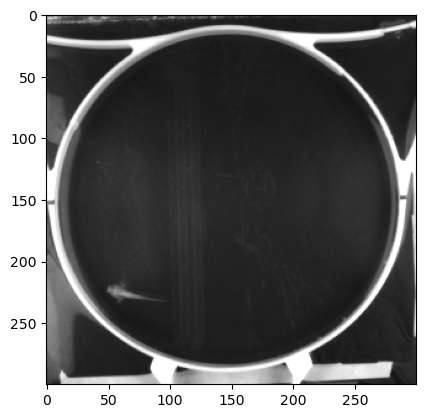

In [58]:
plt.imshow(frame,'gray')

In [59]:
#gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#blur_frame = cv2.medianBlur(gray_frame, 5)
print(blur_frame.shape)

#minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
#maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))


#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 4, minRadius = 120, maxRadius = 140)
#circles = np.uint8(np.around(circles))

circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = 1, minDist = 4, 
                           #param1=100, param2=50, 
                           minRadius = minRadius_init, maxRadius = maxRadius_init) ## add param1 and param2; reduce the distance 
    
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = 1.5, minDist = 2, param1=100, param2=50, minRadius = 120, maxRadius = 140)
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")

    # Sort by radius, smallest first
    circles = sorted(circles, key=lambda c: c[2])

    # Smallest circle
    circle_run = circles[0]
    circle_x = circle_run[0]
    circle_y = circle_run[1] 
    #circle_radius = circle_run[2]  - 6
    circle_radius = circle_run[2] - 4
        
    circle_position = [circle_x, circle_y, circle_radius]
    
#print(circles)
print(circle_position)

try:
    circle_new = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
    #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
    print(circle_new)
    
    if circle_new is not None and circle_new[2] > 110:
        circle_new[2] = circle_new[2] - 4
        circle_position = circle_new
    
except:
    
    print("error in the alternative circle searching")
    
                
#circles = np.uint8(np.around(circles))    
#if len(circles) == 1:
#   circle_run = circles[0,:][0]
           #circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
    #circle_position.to_csv(output_circle, sep=',')
#print(circles)

(300, 300)
[np.int64(144), np.int64(148), np.int64(129)]
[147, 150, 137]


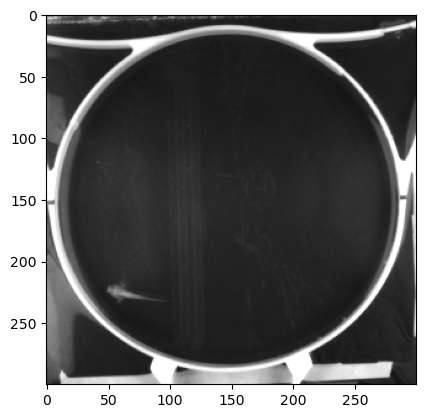

In [60]:
plt.imshow(frame,'gray')

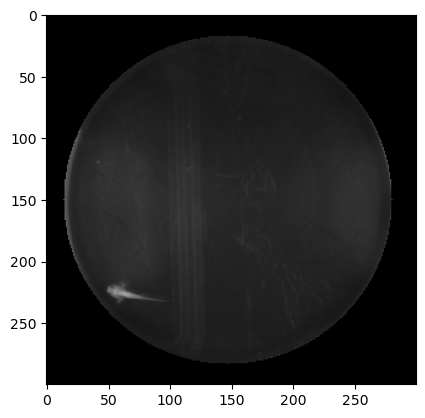

In [61]:
# Apply mask to the area of interest
#frame_0 = frame
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
frame[mask ==  0] = 0
plt.imshow(frame,'gray')

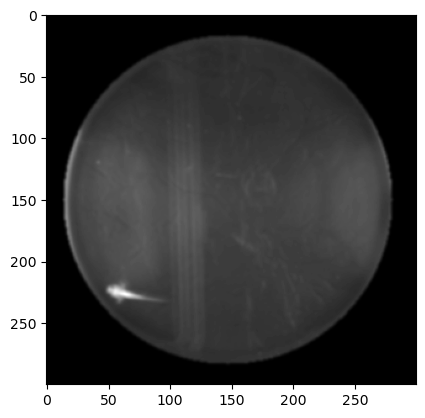

In [62]:
blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#blur = cv2.medianBlur(blur, 5)
blur = cv2.GaussianBlur(blur, (5, 5), 0)
plt.imshow(blur,'gray')

In [108]:
# Apply mask to the area of interest
#mask = np.zeros(frame_0.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
#mask = cv2.circle(mask, (circle_new[0], circle_new[1]), circle_new[2]-2, (255,255,255), -1)
#frame_0[mask ==  0] = 0
#plt.imshow(frame_0,'gray')

In [63]:
this

701.0

7966.0
(300, 300, 3)


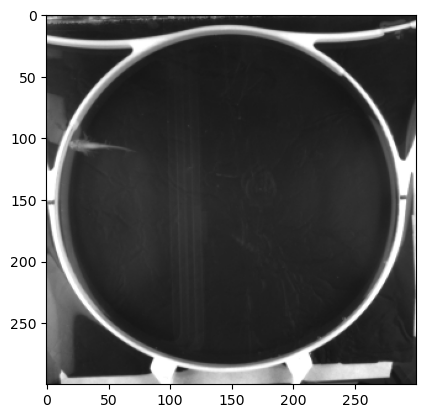

In [64]:
cap.set(1, 7965)
#threshold_value = 120
ret, frame = cap.read()
#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)

this = cap.get(1)
print(this)
#frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
print(frame.shape)
plt.imshow(frame,'gray')

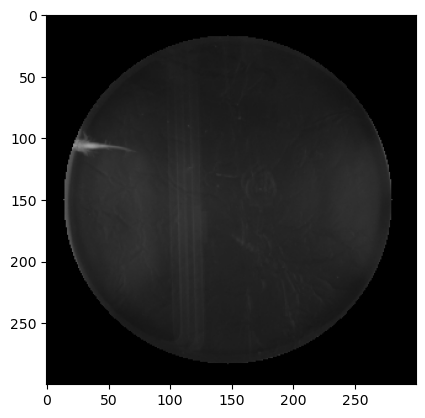

In [65]:
# Apply mask to the area of interest
mask = np.zeros(frame.shape)
mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
#mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)

frame[mask ==  0] = 0
        
blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#blur = cv2.medianBlur(blur, 5)
blur = cv2.GaussianBlur(blur, (5, 5), 0)

plt.imshow(frame,'gray')

In [66]:
#blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#blur = cv2.medianBlur(blur, 5)
#blur = cv2.GaussianBlur(blur, (5, 5), 0)
#plt.imshow(blur_ring,'gray')

otsu_threshold, image_th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU, )
print("Obtained threshold: ", otsu_threshold)

triangle_threshold, th_triangle = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)
print("Obtained threshold: ", triangle_threshold)

#thresh_cell = filters.threshold_minimum(blur, )
#print("Obtained threshold: ", thresh_cell)

Obtained threshold:  18.0
Obtained threshold:  2.0


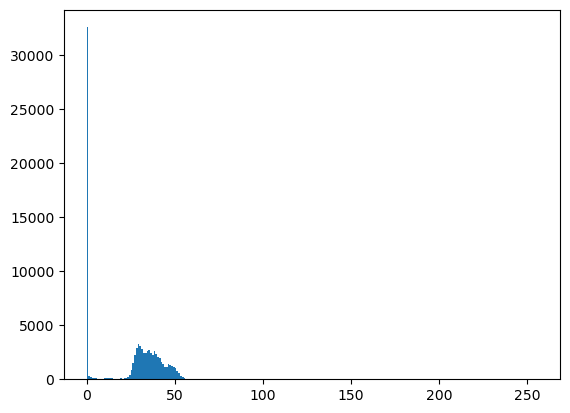

In [67]:
plt.hist(blur.ravel(), bins=256, range=(0, 256))
plt.show()

In [68]:
print(np.quantile(blur.ravel(), 0.995))
print(np.quantile(blur.ravel(), 0.997))
print(np.quantile(blur.ravel(), 0.998))
print(np.quantile(blur.ravel(), 0.999))

62.0
73.0
80.0
109.0


In [69]:
#threshold_value = np.quantile(blur.ravel(), 0.995)
print((blur.ravel() >= np.quantile(blur.ravel(), 0.995)).sum())
#threshold_value = np.quantile(blur.ravel(), 0.997)
#print((blur.ravel() >= np.quantile(blur.ravel(), 0.996)).sum())
print((blur.ravel() >= np.quantile(blur.ravel(), 0.997)).sum())
print((blur.ravel() >= np.quantile(blur.ravel(), 0.998)).sum())
print((blur.ravel() >= np.quantile(blur.ravel(), 0.999)).sum())

456
282
181
95


In [79]:
threshold_value = np.quantile(blur.ravel(), 0.998)
print(threshold_value)
print((blur.ravel() >= np.quantile(blur.ravel(), 0.998)).sum())
#threshold_value = 120

80.0
181


In [80]:
_, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
#thresh = tr.colour_to_thresh(frame, block_size, offset)
thresh = binary
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, 500, min_circularity = 0.1)

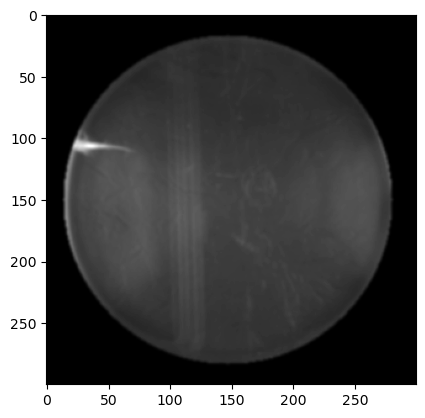

In [81]:
plt.imshow(frame,'gray'); plt.imshow(blur,'gray')

In [82]:
contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [83]:
len(contours)

1

In [85]:
i = 0
area = cv2.contourArea(contours[i])
perimeter = cv2.arcLength(contours[i], True)
circularity = 4 * np.pi * area / (perimeter * perimeter)
print([area, circularity])

[146.0, 0.37658624127552726]


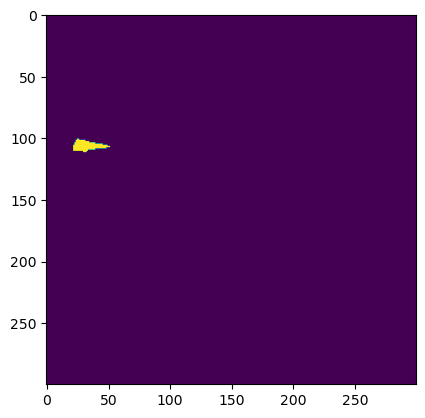

In [86]:
plt.imshow(binary)

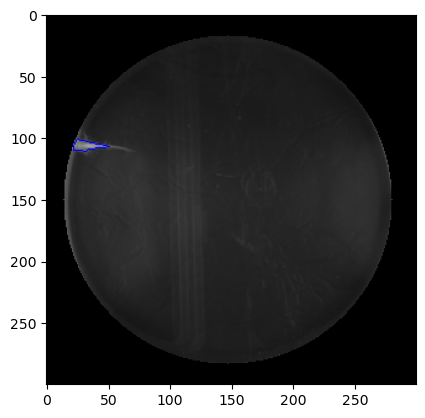

In [87]:
plt.imshow(final,'gray')

In [88]:
print(min_area, max_area), print(int(cv2.__version__[0]))

100 800
4


(None, None)

In [89]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
plt.imshow(final,'gray')

IndexError: tuple index out of range

In [47]:
#### start to run specific examples

In [124]:
print(circle_position)

[150, 152, 135]


In [125]:
#circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
#circle_position.to_csv(output_circle, sep=',')
circle_coord = circle_position.extend([img_shape[0], img_shape[1], scaling_img_0, scaling_img_1])
circle_coord = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius', 'originalImage_x', 'originalImage_y', 'scaling_x', 'scaling_y'])
        
circle_coord.to_csv(output_circle, sep=',')

In [126]:
## try to speed up the cv2 calling 
print(cv2.useOptimized())
cv2.setUseOptimized(True)
print(os.cpu_count())
cv2.setNumThreads(1)

True
10


In [128]:
threshold_quantile = 0.997
print(threshold_quantile)

0.997


In [ ]:
start = time.time()
while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()
        
    this = cap.get(1)
    
    if ret == True:
        frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        
        # Apply mask to the area of interest
        mask = np.zeros(frame.shape)
        mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
        #mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
        frame[mask ==  0] = 0
        
        blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.medianBlur(blur, 5)
            
        threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
        _, thresh = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
        #thresh = tr.colour_to_thresh(frame, block_size, offset)
        #thresh = binary
        final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
        
        try:
            row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
            final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
        except:
            #print(this,  "frame Error")
            err.append([f_newname, this])        
            continue
            
        # Create output dataframe
        for i in range(n_inds):
            df.append([this, meas_now[i][0], meas_now[i][1]])
        
        # save the resulting frame and display some of them
        out.write(final)
        
        if this % 10 == 0:
            cv2.imshow('frame', final)
            if cv2.waitKey(1) == 27:
                break
               
    if last == this:
        break
    
    last = this
    
## Write positions to file
if len(df) > 0:
    df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
    df.to_csv(output_filepath, sep=',')

if len(err) > 0:
    err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
    err.to_csv(output_error, sep=',')
    
## When everything done, release the capture
cap.release()
out.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

####################################
# Plot tracks
# The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
####################################
#if Path(output_filepath).is_file():
if os.path.isfile(output_filepath):
    df = pd.read_csv(output_filepath)
        
    plt.figure(figsize=(8, 8))
    plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
    plt.xlabel('pos_x')
    plt.ylabel('pos_y')
    plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
    plt.close()
        
else:
    print(' no frame processed !!! ')
        
## End time and duration
end = time.time()
duration = np.around((end - start)/60)

print("--- %s minutes ---" %duration)

In [ ]:
#####################################################################
##
## test part for function circle_ostu_floodfill_contour_mincircle
##
#####################################################################

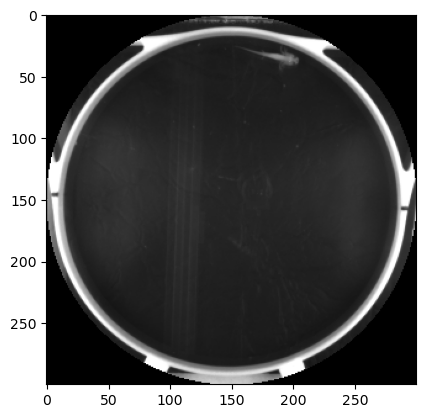

In [42]:
# Apply mask to the area of interest
frame_ring = frame
mask_ring = np.zeros(frame_ring.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask_ring = cv2.circle(mask_ring, (150, 150), 150 , (255,255,255), -1)

frame_ring[mask_ring ==  0] = 0
plt.imshow(frame_ring,'gray')

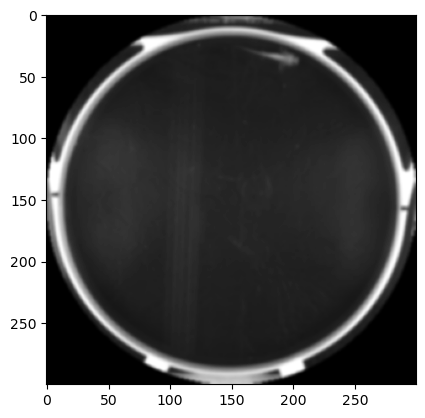

In [44]:
## gaussian blur
gray_ring = cv2.cvtColor(frame_ring, cv2.COLOR_BGR2GRAY)
blur_ring = cv2.GaussianBlur(gray_ring, (5, 5), 0)
plt.imshow(blur_ring,'gray')

Obtained threshold:  108.0


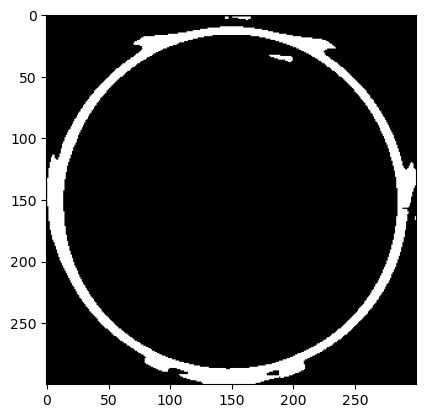

In [45]:
# Applying Otsu's method setting the flag value into cv.THRESH_OTSU.
# Use a bimodal image as an input.
# Optimal threshold value is determined automatically.
otsu_threshold, image_th = cv2.threshold(
    blur_ring, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)
print("Obtained threshold: ", otsu_threshold)
plt.imshow(image_th,'gray')

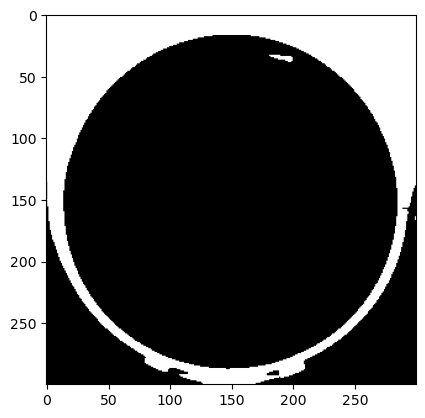

In [46]:
# Copy the thresholded image.
im_floodfill = image_th.copy()
# Mask used to flood filling.
# Notice the size needs to be 2 pixels than the image.
h, w = image_th.shape[:2]
mask_floodfill = np.zeros((h+2, w+2), np.uint8)
 
# Floodfill from point (0, 0)
cv2.floodFill(im_floodfill, mask_floodfill, (0,0), 255);
#cv2.floodFill(im_floodfill, mask_floodfill, (250,250), 255);
plt.imshow(im_floodfill,'gray')

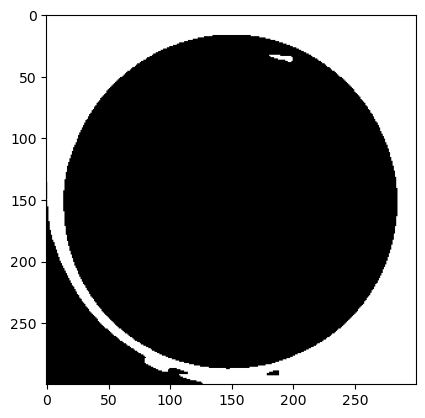

In [47]:
cv2.floodFill(im_floodfill, mask_floodfill, (299, 299), 255);
plt.imshow(im_floodfill,'gray')

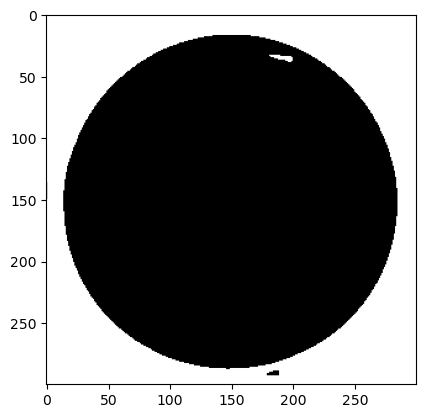

In [48]:
cv2.floodFill(im_floodfill, mask_floodfill, (0, 299), 255);
plt.imshow(im_floodfill,'gray')

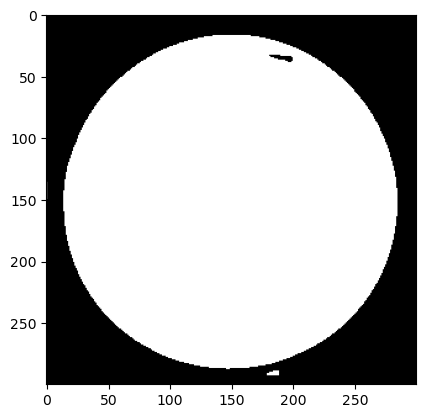

In [49]:
# Invert floodfilled image
im_floodfill_inv = cv2.bitwise_not(im_floodfill)
plt.imshow(im_floodfill_inv,'gray')

In [ ]:
contours, hierarchy = cv2.findContours(
    im_floodfill_inv,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
disk = np.zeros_like(im_floodfill_inv)

if contours:
    biggest_contour = max(contours, key=cv2.contourArea)
    
    (x, y), radius = cv2.minEnclosingCircle(biggest_contour)
    center = (int(x), int(y))
    radius = int(radius)
    print("Center:", center)
    print("Radius:", radius)
    
    # Draw circle for visualization
    
    output = cv2.cvtColor(im_floodfill_inv, cv2.COLOR_GRAY2BGR)
    cv2.circle(output, center, radius, (0, 255, 0), 2)
    cv2.circle(output, center, 2, (0, 0, 255), 3)
    
    cv2.imshow("Minimal enclosing circle", output)
    cv2.waitKey(0)
    
    #cv2.drawContours(disk, [biggest_contour], -1, 255, thickness=cv2.FILLED)
    
#plt.imshow(disk,'gray')


Center: (148, 151)
Radius: 135
